# E($n$)-Equivariant Spherical Decision Surfaces

This notebook implements the constructions from the paper and numerically verifies exact equivariance, including equation references from the manuscript:

- Regular simplex $P_n$ and change-of-basis $M_n$ (Sec. 2.1; Eq. (1)–(4)).
- Spherical neuron and O($n$)-equivariant hypersphere $B(S)$ from prior work (Sec. 2.3–2.4; Eq. (7)–(16)).
- Homogeneous lift $B_{\mathrm{hom}}(S)$, translation representation $T(t)$ (Sec. 3.2; Eq. (22), (24), (28)–(31)).
- Full E($n$) representation $Q(R,t)=T(t)\,V(R)$ (Sec. 3.3; Eq. (32), (37)–(39)).
- Identity split and invariants $I_i$, $I_{ij}$ (Sec. 3.1 & 3.4; Eq. (18), (41)–(43)).

All computations use PyTorch in double precision.


In [1]:
import sys
import math
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', DEVICE)

device = cpu


In [2]:
print(f'Versions: python {sys.version}, torch {torch.__version__}, numpy {np.__version__}')

Versions: python 3.10.12 (main, Jul  5 2023, 15:02:25) [Clang 14.0.6 ], torch 2.1.0, numpy 1.25.0



## Regular simplex $P_n$ and change-of-basis matrix $M_n$ 
Sec. 2.1; Eq. (1)–(4).


In [3]:
@torch.no_grad()
def regular_simplex(n: int, device=DEVICE):
    """Regular simplex P_n with n+1 unit vertices in R^n (columns)."""
    P = torch.zeros(n+1, n)

    # calculate vertices of the regular n-simplex:
    kappa = - (1 + (n + 1)**(1/2)) / (n**(3/2))
    mu = (1 + 1 / n)**(1/2)
    P[0, :] = 1 / n**(1/2)
    for i in range(1, n + 1):
        P[i, :] = kappa + mu * torch.eye(n)[i - 1]

    return P.T

@torch.no_grad()
def build_Mn(P_n: torch.Tensor):
    """Eq. (3): columns m_i = (1/p) [p_i ; n^{-1/2}], with p = sqrt((n+1)/n)."""
    n, n1 = P_n.shape
    assert n1 == n+1
    p = math.sqrt((n+1)/n)
    last = (1.0/math.sqrt(n)) * torch.ones(1, n+1, device=P_n.device, dtype=P_n.dtype)
    M_raw = torch.vstack([P_n, last])
    M = M_raw / p  # divide ENTIRE column by p
    # orthonormality check
    e_orth = torch.norm(M.T @ M - torch.eye(n+1, device=P_n.device, dtype=P_n.dtype))
    return M, p, e_orth

@torch.no_grad()
def check_eq4(M_n, P_n, p):
    """Eq. (4): M_n P_n^T = p [ I_n ; 0^T ]."""
    n = P_n.shape[0]
    rhs = torch.zeros(n+1, n, device=P_n.device, dtype=P_n.dtype)
    rhs[:n, :n] = torch.eye(n, device=P_n.device, dtype=P_n.dtype)
    lhs = M_n @ P_n.T
    return torch.norm(lhs - p * rhs)

for n in (2, 3, 4, 5):
    P_n = regular_simplex(n)
    M_n, p, e_orth = build_Mn(P_n)
    e_eq4 = check_eq4(M_n, P_n, p)
    print(f"n={n}: ||M^T M - I||={e_orth.item():.2e},  Eq(4) error={e_eq4.item():.2e}")


n=2: ||M^T M - I||=1.65e-16,  Eq(4) error=5.15e-18
n=3: ||M^T M - I||=6.61e-16,  Eq(4) error=3.01e-16
n=4: ||M^T M - I||=2.46e-16,  Eq(4) error=1.57e-16
n=5: ||M^T M - I||=3.26e-16,  Eq(4) error=2.02e-16



## Embedding and spherical neuron  
**Refs:** Sec. 2.3; Eq. (7)–(11).


In [4]:

@torch.no_grad()
def embed_X(x: torch.Tensor) -> torch.Tensor:
    return torch.cat([x, torch.tensor([-1.0], device=x.device, dtype=x.dtype),
                      -0.5*torch.tensor([x.dot(x)], device=x.device, dtype=x.dtype)])

@torch.no_grad()
def embed_S(c: torch.Tensor, r: torch.Tensor, gamma: float = 1.0) -> torch.Tensor:
    s_last = torch.tensor([0.5*(c.dot(c) - r*r), gamma], device=c.device, dtype=c.dtype)
    return torch.cat([c, s_last])


@torch.no_grad()
def unembed_X_embedded(X: torch.Tensor) -> torch.Tensor:
    """Unembed for the scheme [x; -1; -0.5||x||^2]: simply return the first n entries.
    """
    n = X.shape[0] - 2
    return X[:n]



## O($n$)-equivariant hypersphere $B(S)$ 
Sec. 2.4; Eq. (12), (14), (16).


In [5]:
@torch.no_grad()
def extend_diag(R: torch.Tensor, out_dim: int) -> torch.Tensor:
    m = R.shape[0]
    I = torch.eye(out_dim, device=R.device, dtype=R.dtype)
    I[:m, :m] = R
    return I

@torch.no_grad()
def rotation_from_to(u: torch.Tensor, v: torch.Tensor) -> torch.Tensor:
    """Shortest rotation (det=+1) mapping u->v. Uses tensor clamp."""
    n = u.numel()
    u = u / (u.norm() + 1e-15)
    v = v / (v.norm() + 1e-15)
    cos_th_t = (u @ v).clamp(-1.0, 1.0)
    cos_th = float(cos_th_t.item())
    if cos_th > 1 - 1e-15:
        return torch.eye(n, device=u.device, dtype=u.dtype)
    if cos_th < -1 + 1e-15:
        w = torch.zeros_like(u)
        w[(u.abs()).argmin()] = 1.0
        w = w - (w @ u) * u
        w = w / (w.norm() + 1e-15)
        H1 = torch.eye(n, device=u.device, dtype=u.dtype) - 2 * torch.outer(w, w)
        a = (-u)
        b = v - (v @ a) * a
        b = b / (b.norm() + 1e-15)
        H2 = torch.eye(n, device=u.device, dtype=u.dtype) - 2 * torch.outer(b, b)
        return H2 @ H1
    a = u
    b = v - (v @ a) * a
    b = b / (b.norm() + 1e-15)
    cos_th = float((v @ a).item())
    sin_th = float((v @ b).item())
    A = torch.stack([a, b], dim=1)
    R2 = torch.tensor([[cos_th, -sin_th], [sin_th, cos_th]], device=u.device, dtype=u.dtype)
    R  = A @ R2 @ A.T + (torch.eye(n, device=u.device, dtype=u.dtype) - A @ A.T)
    return R

@torch.no_grad()
def build_R_T_list(P_n: torch.Tensor) -> torch.Tensor:
    n, n1 = P_n.shape
    R_T = []
    p1 = P_n[:, 0]
    for i in range(n1):
        pi = P_n[:, i]
        R = rotation_from_to(p1, pi)
        R_T.append(R)
    return torch.stack(R_T, dim=0)

@torch.no_grad()
def geodesic_R_O(c: torch.Tensor, p1: torch.Tensor) -> torch.Tensor:
    cn = c.norm()
    if cn < 1e-12:
        return torch.eye(c.numel(), device=c.device, dtype=c.dtype)
    return rotation_from_to(c/cn, p1)

@torch.no_grad()
def B_matrix(S: torch.Tensor, R_O: torch.Tensor, R_T_list: torch.Tensor) -> torch.Tensor:
    n = R_O.shape[0]
    rows = []
    R_O_ext = extend_diag(R_O, n+2)
    for i in range(R_T_list.shape[0]):
        R_ext = extend_diag(R_T_list[i], n+2)
        rows.append((R_O_ext.T @ R_ext @ R_O_ext @ S).unsqueeze(0))
    return torch.cat(rows, dim=0)

@torch.no_grad()
def V_matrix(R: torch.Tensor, M_n: torch.Tensor, R_O: torch.Tensor) -> torch.Tensor:
    return M_n.T @ extend_diag(R_O, M_n.shape[0]) @ extend_diag(R, M_n.shape[0]) @ extend_diag(R_O.T, M_n.shape[0]) @ M_n



## Homogeneous lift, translations, and full E($n$)  
Sec. 3.2–3.3; Eq. (22), (24), (28)–(31), (37).


In [6]:

@torch.no_grad()
def B_hom_matrix(B: torch.Tensor, p: float, c: torch.Tensor, gamma: float = 1.0) -> torch.Tensor:
    n1, n2 = B.shape
    last = torch.zeros(n2, device=B.device, dtype=B.dtype)
    last[-2] = -gamma * p * c.norm()
    return torch.vstack([gamma * B, last.unsqueeze(0)])

@torch.no_grad()
def T_RHS_matrix(t: torch.Tensor) -> torch.Tensor:
    n = t.numel()
    T = torch.eye(n+2, device=t.device, dtype=t.dtype)
    T[:n, n] = -t
    T[-1, :n] = -t
    T[-1, n] = 0.5 * t.dot(t)
    return T

@torch.no_grad()
def alpha_from_c(c: torch.Tensor) -> float:
    n = c.numel()
    cn = c.norm()
    if cn < 1e-12:
        cn = torch.tensor(1e-12, device=c.device, dtype=c.dtype)
    return math.sqrt(n) / (2.0 * float(cn.item()))

@torch.no_grad()
def T_interm_matrix(t: torch.Tensor, alpha: float) -> torch.Tensor:
    n = t.numel()
    T = torch.eye(n+2, device=t.device, dtype=t.dtype)
    T[:n, -1] = t
    T[n, :n] = -2*alpha*t
    T[n, -1] = -alpha * t.dot(t)
    return T

@torch.no_grad()
def T_full_matrix(t: torch.Tensor, M_n: torch.Tensor, R_O: torch.Tensor, alpha: float) -> torch.Tensor:
    n = t.numel()
    Tinter = T_interm_matrix(t, alpha)
    Mext = extend_diag(M_n, n+2)
    ROext = extend_diag(R_O, n+2)
    return Mext.T @ ROext @ Tinter @ ROext.T @ Mext

@torch.no_grad()
def T_full_inverse(t: torch.Tensor, M_n: torch.Tensor, R_O: torch.Tensor, alpha: float) -> torch.Tensor:
    n = t.numel()
    Tinv = torch.eye(n+2, device=t.device, dtype=t.dtype)
    Tinv[:n, -1] = -t
    Tinv[n, :n] =  2*alpha*t
    Tinv[n, -1] = -alpha * t.dot(t)
    Mext = extend_diag(M_n, n+2)
    ROext = extend_diag(R_O, n+2)
    return Mext.T @ ROext @ Tinv @ ROext.T @ Mext

@torch.no_grad()
def Q_RHS_matrix(R: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    n = t.numel()
    Q = torch.eye(n+2, device=t.device, dtype=t.dtype)
    Q[:n, :n] = R
    Q[:n, n] = -t
    Q[-1, :n] = -t @ R
    Q[-1, n] = 0.5 * t.dot(t)
    return Q

@torch.no_grad()
def Q_full_matrix(R: torch.Tensor, t: torch.Tensor, M_n: torch.Tensor, R_O: torch.Tensor, alpha: float) -> torch.Tensor:
    V = M_n.T @ extend_diag(R_O, M_n.shape[0]) @ extend_diag(R, M_n.shape[0]) @ extend_diag(R_O.T, M_n.shape[0]) @ M_n
    Vext = extend_diag(V, t.numel()+2)
    Tfull = T_full_matrix(t, M_n, R_O, alpha)
    return Tfull @ Vext



## Identity split & invariants  
Sec. 3.1 & 3.4; Eq. (18), (41)–(43).


In [7]:

@torch.no_grad()
def identity_split_check(x, c, r, P_n, M_n, R_O, R_T_list):
    S = embed_S(c, r)
    B = B_matrix(S, R_O, R_T_list)
    X = embed_X(x)
    y = B @ X
    n = x.numel()
    p = math.sqrt((n+1)/n)
    left = extend_diag(R_O, n+1).T @ M_n @ y
    alpha = math.sqrt(n)/(2.0*max(c.norm().item(), 1e-12))
    right = p*c.norm() * torch.cat([x, torch.tensor([alpha*(r*r - c.dot(c) - x.dot(x))], device=x.device, dtype=x.dtype)])
    return torch.norm(left - right)

@torch.no_grad()
def canonical_triplet(x, c, r, P_n, M_n, R_O, R_T_list):
    S = embed_S(c, r)
    B = B_matrix(S, R_O, R_T_list)
    X = embed_X(x)
    y = B @ X
    n = x.numel()
    p = math.sqrt((n+1)/n)
    z = (extend_diag(R_O, n+1).T @ M_n @ y) / (p*max(c.norm(), torch.tensor(1e-12, device=x.device)))
    x_can = z[:n]
    s = z[-1]
    alpha = math.sqrt(n)/(2.0*max(c.norm().item(), 1e-12))
    return x_can, s, alpha



## Numerical experiments
We verify: identity split (Eq. 18), translation Eq. (27), full E($n$) Eq. (32), inverse & composition Eqs. (30–31), (38–39), and invariants Eqs. (41)–(43). The $I_{ij}$ check uses one neuron (with $\alpha_k$) and cross‑checks Eq. (42) and Eq. (43).


In [8]:

@torch.no_grad()
def run_checks(n=3, trials=200, t_scale=3.0):
    errs_split = []
    errs_T = []
    errs_Q = []
    errs_Tinv = []
    errs_Qgroup = []
    errs_Ii = []
    errs_Iij = []

    P_n = regular_simplex(n)
    M_n, p, _ = build_Mn(P_n)
    R_T_list = build_R_T_list(P_n)
    p1 = P_n[:, 0]

    for _ in range(trials):
        x = torch.randn(n, device=DEVICE)
        c = torch.randn(n, device=DEVICE)
        if c.norm() < 0.01:
            c = c + 0.5*torch.randn(n, device=DEVICE)
        r = torch.randn(1, device=DEVICE)[0]

        R_O = geodesic_R_O(c, p1)
        S = embed_S(c, r)
        B = B_matrix(S, R_O, R_T_list)
        Bh = B_hom_matrix(B, p, c)
        X = embed_X(x)

        # Eq. (18)
        errs_split.append(identity_split_check(x, c, r, P_n, M_n, R_O, R_T_list).item())

        # Translation Eq. (27)
        t = t_scale * torch.randn(n, device=DEVICE)
        alpha = alpha_from_c(c)
        T_rhs = T_RHS_matrix(t)
        T_full = T_full_matrix(t, M_n, R_O, alpha)
        errs_T.append(torch.norm(T_full @ Bh @ X - Bh @ T_rhs @ X).item())

        # Full E(n) Eq. (32)
        A = torch.randn(n, n, device=DEVICE)
        Qrot, _ = torch.linalg.qr(A)
        R = Qrot
        Q_rhs = Q_RHS_matrix(R, t)
        Q_full = Q_full_matrix(R, t, M_n, R_O, alpha)
        errs_Q.append(torch.norm(Q_full @ Bh @ X - Bh @ Q_rhs @ X).item())

        # Inverse & composition
        T_inv = T_full_inverse(t, M_n, R_O, alpha)
        I = torch.eye(n+2, device=DEVICE)
        errs_Tinv.append((torch.norm(T_full @ T_inv - I) + torch.norm(T_inv @ T_full - I)).item())

        # Group law Eq. (39)
        A1 = torch.randn(n, n, device=DEVICE); Q1,_ = torch.linalg.qr(A1)
        A2 = torch.randn(n, n, device=DEVICE); Q2,_ = torch.linalg.qr(A2)
        t1 = t_scale * torch.randn(n, device=DEVICE)
        t2 = t_scale * torch.randn(n, device=DEVICE)
        Q12 = Q_full_matrix(Q2, t2, M_n, R_O, alpha) @ Q_full_matrix(Q1, t1, M_n, R_O, alpha)
        Q_comp = Q_full_matrix(Q2@Q1, Q2@t1 + t2, M_n, R_O, alpha)
        errs_Qgroup.append(torch.norm(Q12 - Q_comp).item())

        # Invariants with a single neuron
        alpha_fixed = alpha_from_c(c)
        x1 = torch.randn(n, device=DEVICE)
        x2 = torch.randn(n, device=DEVICE)
        x1c, s1, _ = canonical_triplet(x1, c, r, P_n, M_n, R_O, R_T_list)
        x2c, s2, _ = canonical_triplet(x2, c, r, P_n, M_n, R_O, R_T_list)
        Ii = s1 + alpha_fixed * x1c.dot(x1c)  # Eq. (41)

        # I_ij via (42) and (43)
        Iij_A = s1 + s2 + 2.0 * alpha_fixed * x1c.dot(x2c)  # (42)
        Iij_B = alpha_fixed * (2.0*r*r - 2.0*c.dot(c) - (x1c - x2c).dot(x1c - x2c))  # (43)

        # Apply same E(n) to both points, unembed, canonicalise
        A3 = torch.randn(n, n, device=DEVICE); R3,_ = torch.linalg.qr(A3)
        t3 = t_scale * torch.randn(n, device=DEVICE)
        X1p = Q_RHS_matrix(R3, t3) @ embed_X(x1)
        X2p = Q_RHS_matrix(R3, t3) @ embed_X(x2)
        x1p = unembed_X_embedded(X1p)
        x2p = unembed_X_embedded(X2p)
        x1c_p, s1_p, _ = canonical_triplet(x1p, c, r, P_n, M_n, R_O, R_T_list)
        x2c_p, s2_p, _ = canonical_triplet(x2p, c, r, P_n, M_n, R_O, R_T_list)
        Ii_p = s1_p + alpha_fixed * x1c_p.dot(x1c_p)

        Iij_A_p = s1_p + s2_p + 2.0 * alpha_fixed * x1c_p.dot(x2c_p)
        Iij_B_p = alpha_fixed * (2.0*r*r - 2.0*c.dot(c) - (x1c_p - x2c_p).dot(x1c_p - x2c_p))

        errs_Ii.append(abs(Ii - Ii_p).item())
        errs_Iij.append((abs(Iij_A - Iij_A_p) + abs(Iij_B - Iij_B_p)
                         + abs(Iij_A - Iij_B)   + abs(Iij_A_p - Iij_B_p)).item())

    return {
        'split': torch.tensor(errs_split),
        'T': torch.tensor(errs_T),
        'Q': torch.tensor(errs_Q),
        'Tinv': torch.tensor(errs_Tinv),
        'Qgroup': torch.tensor(errs_Qgroup),
        'Ii': torch.tensor(errs_Ii),
        'Iij': torch.tensor(errs_Iij),
    }

res2 = run_checks(n=2, trials=1000)
res3 = run_checks(n=3, trials=1000)
res4 = run_checks(n=4, trials=1000)
res5 = run_checks(n=5, trials=1000)
print('median errors (n=2):', {k: v.median().item() for k,v in res2.items()})
print('median errors (n=3):', {k: v.median().item() for k,v in res3.items()})
print('median errors (n=4):', {k: v.median().item() for k,v in res4.items()})
print('median errors (n=5):', {k: v.median().item() for k,v in res5.items()})


median errors (n=2): {'split': 2.2853948377776767e-14, 'T': 8.063192968014449e-14, 'Q': 1.0864858298996458e-13, 'Tinv': 2.197915998841762e-13, 'Qgroup': 1.571799790994758e-13, 'Ii': 1.8618440122963875e-13, 'Iij': 9.362510766663945e-13}
median errors (n=3): {'split': 3.251420342428096e-14, 'T': 1.0763461921740504e-13, 'Q': 1.3022797768104182e-13, 'Tinv': 2.436111056077472e-13, 'Qgroup': 1.4509323719851773e-13, 'Ii': 2.4491519923230953e-13, 'Iij': 1.2185807918285718e-12}
median errors (n=4): {'split': 3.9432146124668265e-14, 'T': 1.3411200035432723e-13, 'Q': 1.5506282723830506e-13, 'Tinv': 2.2743310081925115e-13, 'Qgroup': 1.4653303731070634e-13, 'Ii': 3.1885605267234496e-13, 'Iij': 1.531219595563016e-12}
median errors (n=5): {'split': 4.661700962234372e-14, 'T': 1.5126176547637617e-13, 'Q': 1.7368373848939196e-13, 'Tinv': 2.0740954467222455e-13, 'Qgroup': 1.3711074629972142e-13, 'Ii': 3.850253449400043e-13, 'Iij': 1.808331262509455e-12}



### Error distributions (log10)


In [9]:

common_keys = res2.keys()
assert common_keys == res3.keys() == res4.keys() == res5.keys(), "Mismatch in metric keys."

# concatenate
res = {
    k: torch.cat([res2[k], res3[k], res4[k], res5[k]], dim=0)
    for k in common_keys
}

# fig, axs = plt.subplots(2, 3, figsize=(12, 7))
# axes = axs.ravel(); labels = ['split','T','Q','Tinv','Qgroup','Iij']
# titles = [
#     "Identity split",
#     r"$\boldsymbol{T}$",
#     r"$\boldsymbol{Q}$",
#     r"$\boldsymbol{T}^{-1}$",
#     r"$\boldsymbol{Q}_{2}\,\boldsymbol{Q}_{1}$",
#     r"$I_{ij}$",
# ]

# for ax, key, title in zip(axes, labels, titles):
#     vals = res[key].cpu().numpy() + 1e-30
#     ax.hist(torch.log10(torch.tensor(vals)).numpy(), bins=30)
#     ax.set_title(title); ax.set_xlabel('log10 error')
# plt.tight_layout()
# plt.show()

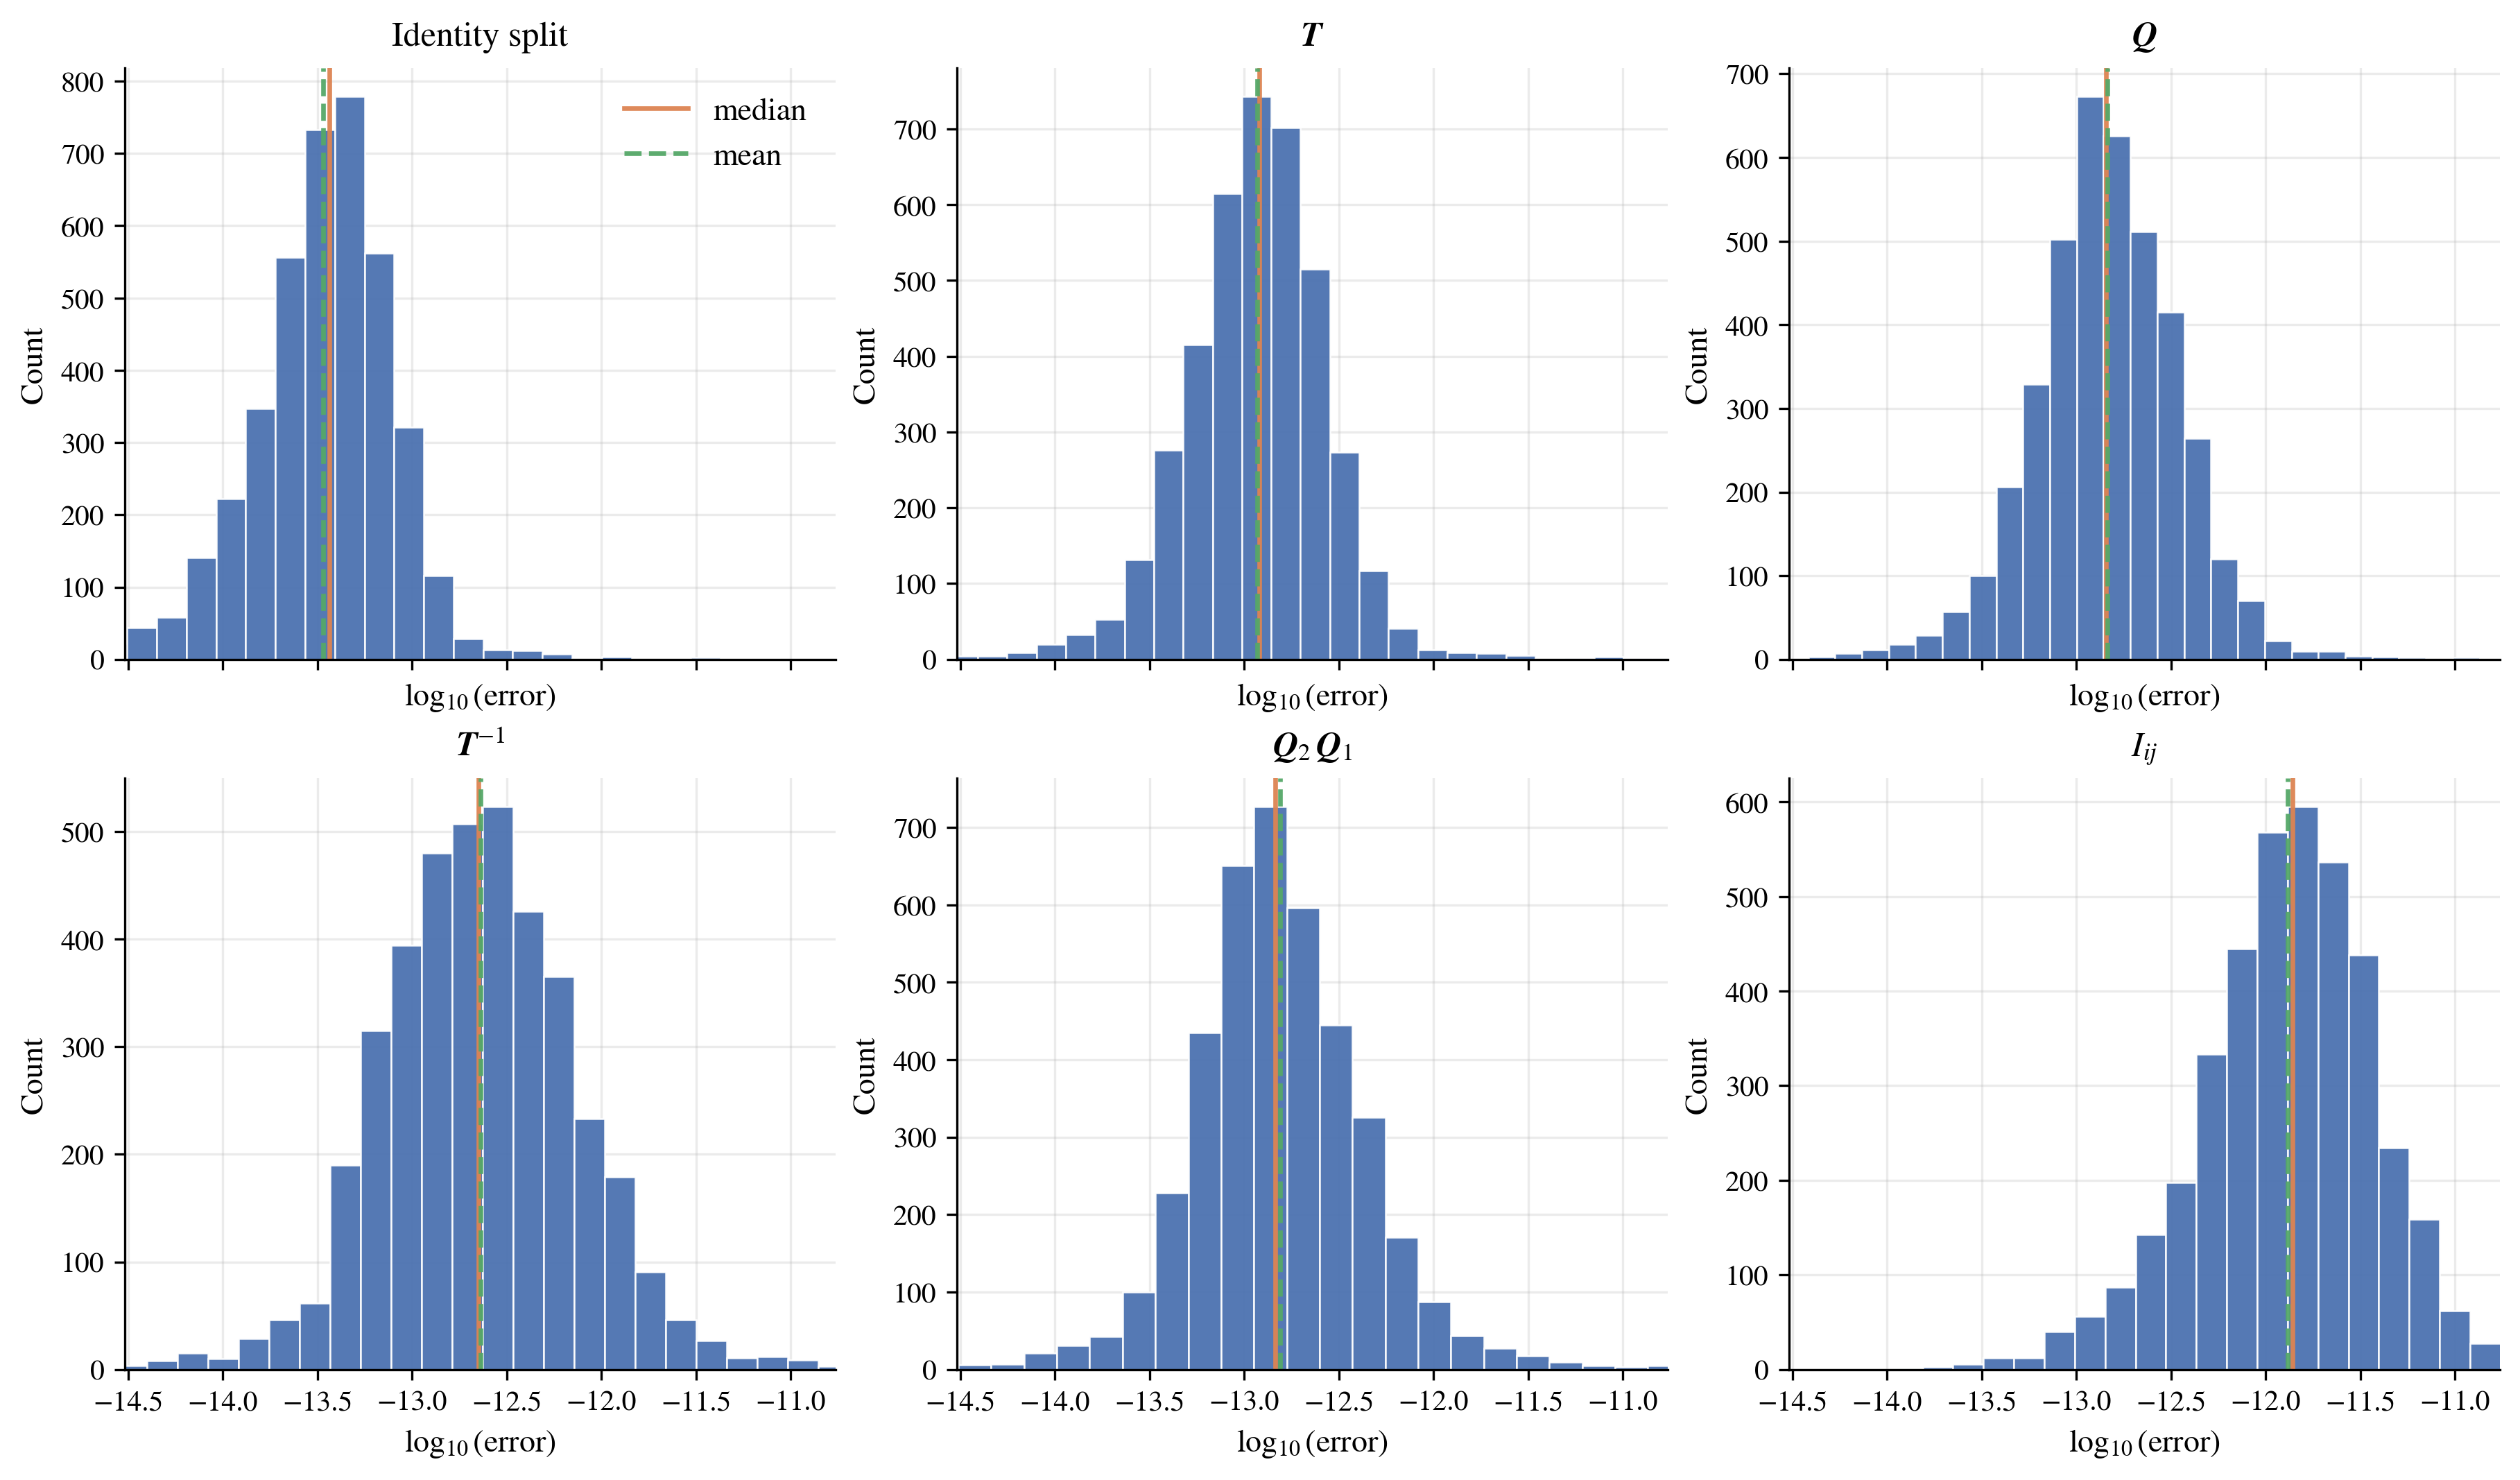

In [10]:
# a nicer plot
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "legend.frameon": False,
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
})

fig, axs = plt.subplots(
    2, 3,
    figsize=(12, 7),
    constrained_layout=True,   
    sharex=True,
)

axes = axs.ravel()

labels = ["split", "T", "Q", "Tinv", "Qgroup", "Iij"]

titles = [
    "Identity split",
    r"$\boldsymbol{T}$",
    r"$\boldsymbol{Q}$",
    r"$\boldsymbol{T}^{-1}$",
    r"$\boldsymbol{Q}_{2}\,\boldsymbol{Q}_{1}$",
    r"$I_{ij}$",
]

bar_color = "#4C72B0"   # muted blue
edge_color = "white"


all_logs = []
per_key_logs = {}

eps = 1e-30  # keeps log10 finite
for key in labels:
    vals = res[key].detach().cpu().numpy().astype(np.float64)
    vals = np.maximum(vals, eps)
    logv = np.log10(vals)

    # drop non-finite values (just in case)
    logv = logv[np.isfinite(logv)]
    per_key_logs[key] = logv
    all_logs.append(logv)

all_logs = np.concatenate(all_logs) if len(all_logs) else np.array([0.0])

x_lo, x_hi = np.percentile(all_logs, [0.5, 99.5])
pad = 0.05 * (x_hi - x_lo + 1e-12)
xlim = (x_lo - pad, x_hi + pad)

for ax, key, title in zip(axes, labels, titles):
    logv = per_key_logs[key]

    ax.hist(
        logv,
        bins=30,
        color=bar_color,
        edgecolor=edge_color,
        linewidth=0.6,
        alpha=0.95,
    )

    if logv.size:
        med = np.median(logv)
        mean = np.mean(logv)
        ax.axvline(med, linestyle="-", linewidth=1.6, color="#DD8452", alpha=0.95, label="median")
        ax.axvline(mean, linestyle="--", linewidth=1.6, color="#55A868", alpha=0.95, label="mean")

    ax.set_title(title, pad=8)
    ax.set_xlabel(r"$\log_{10}(\mathrm{error})$")
    ax.set_ylabel("Count")
    ax.set_xlim(*xlim)

handles, legend_labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(handles, legend_labels, loc="upper right")

plt.savefig("equivariance_error_histograms.pdf", bbox_inches="tight")
plt.show()